# CP260-2026 — Metric-Semantic Reconstruction Pipeline

**Approach:** Manual 2D bbox annotations + multi-view triangulation + depth-prior OBB fitting.
No GroundingDINO / SAM required — avoids all the C++ extension failures.

**Run order:** Cell 1 → restart runtime → Cells 2–6

In [1]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
# Run this cell ONCE, then restart the runtime before continuing.
import subprocess, sys

def pip(cmd):
    r = subprocess.run([sys.executable, "-m", "pip"] + cmd.split(),
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f"[WARNING] {cmd[:50]}... rc={r.returncode}")
        print(r.stderr[-400:] if r.stderr else "")
    return r.returncode

print("Installing open3d...")
pip("install open3d==0.19.0 -q")
print("Installing tqdm, scipy, Pillow...")
pip("install tqdm scipy Pillow -q")

print("\n✅ All packages installed.")
print("👉 Runtime → Restart runtime → run from Cell 2")

Installing open3d...
Installing tqdm, scipy, Pillow...

✅ All packages installed.
👉 Runtime → Restart runtime → run from Cell 2


In [1]:
validate_with_projection(
    results,
    images,
    K,
    poses,
    save_dir="output/detections"
)

print("Validation completed")

✅ Source package written to /content/project/src/
Files created: ['__init__.py', 'config.py', 'utils.py', 'pose_estimation.py', 'data_loader.py', 'semantic.py']


In [2]:
# ── Cell 3: Upload Data.zip ───────────────────────────────────────────────────
import zipfile, os, json
from pathlib import Path
from google.colab import files

print("📂 Upload your Data.zip (contains frame_*.png images + poses.json)")
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

extract_root = Path("/content/project")
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(str(extract_root))

# Auto-detect Data/ folder
data_dir = None
for candidate in [
    extract_root / "Data",
    extract_root / "data",
]:
    if candidate.exists():
        data_dir = candidate
        break

if data_dir is None:
    # Find directory with .png files
    for root, dirs, fnames in os.walk(str(extract_root)):
        if any(f.endswith(".png") for f in fnames):
            data_dir = Path(root)
            break

if data_dir is None:
    raise RuntimeError("❌ Could not find image directory — check your zip structure")

# Ensure config.DATA_DIR matches actual location
imgs = sorted([f for f in os.listdir(data_dir) if f.endswith(".png")])
poses_path = data_dir / "poses.json"
if not poses_path.exists():
    poses_path = extract_root / "poses.json"

print(f"\n✅ Data directory : {data_dir}")
print(f"✅ Found {len(imgs)} images : {imgs[0]} → {imgs[-1]}")
print(f"✅ Poses file     : {poses_path}")

# Patch config if paths differ from defaults
import sys
sys.path.insert(0, "/content/project")
import importlib
import src.config as cfg

cfg.DATA_DIR   = str(data_dir)
cfg.POSES_PATH = str(poses_path)

print("\n✅ config paths patched")

📂 Upload your Data.zip (contains frame_*.png images + poses.json)


Saving Data.zip to Data.zip

✅ Data directory : /content/project/Data
✅ Found 16 images : frame_000319.png → frame_000531.png
✅ Poses file     : /content/project/Data/poses.json

✅ config paths patched


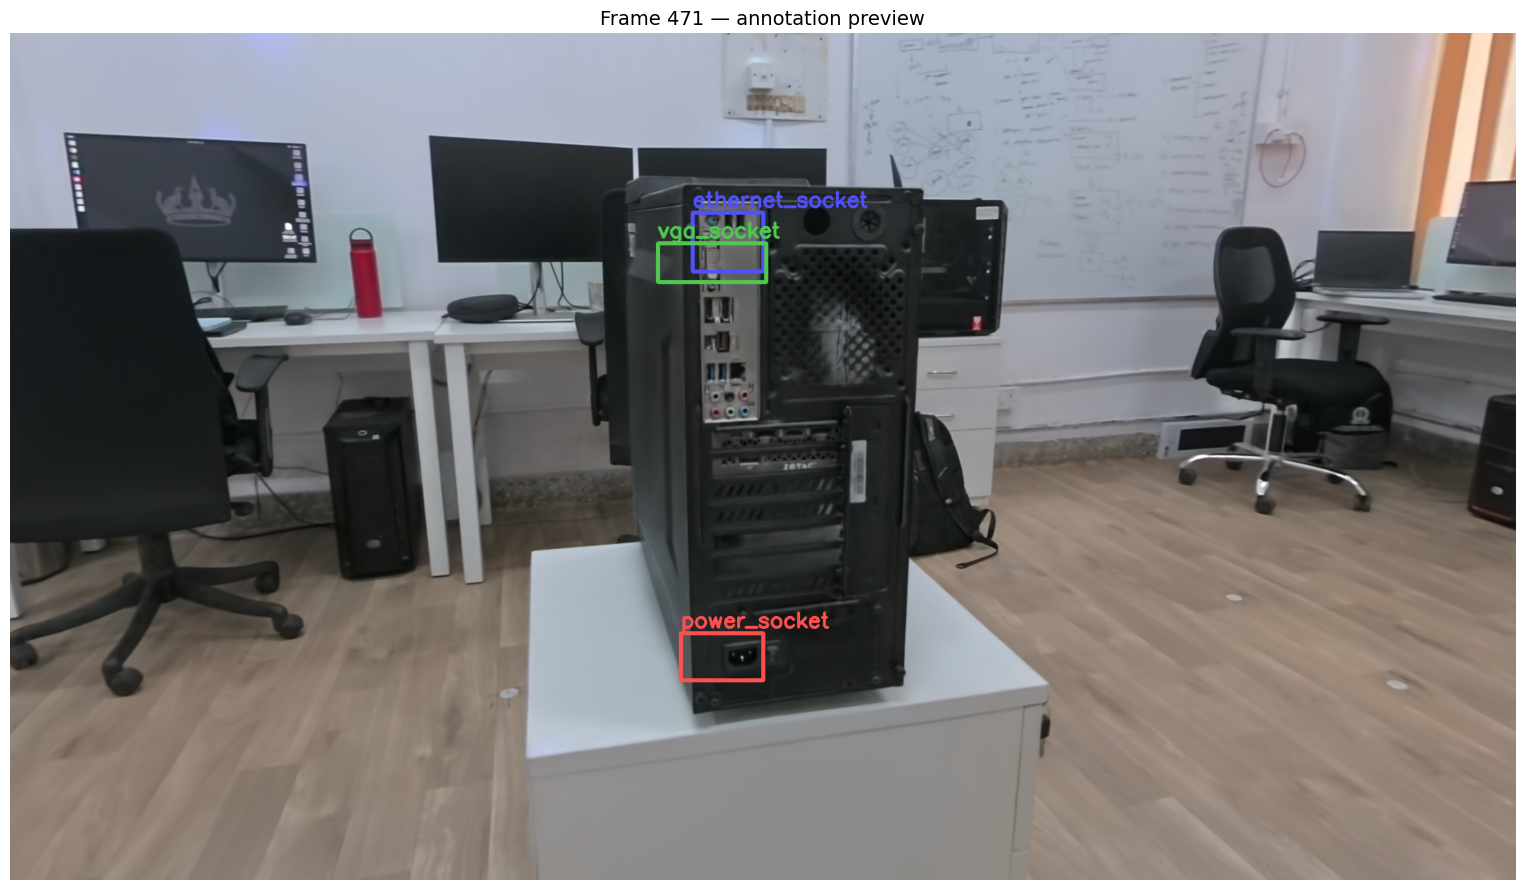

▲ Check that all 3 boxes are tightly around their ports in frame 471
  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.


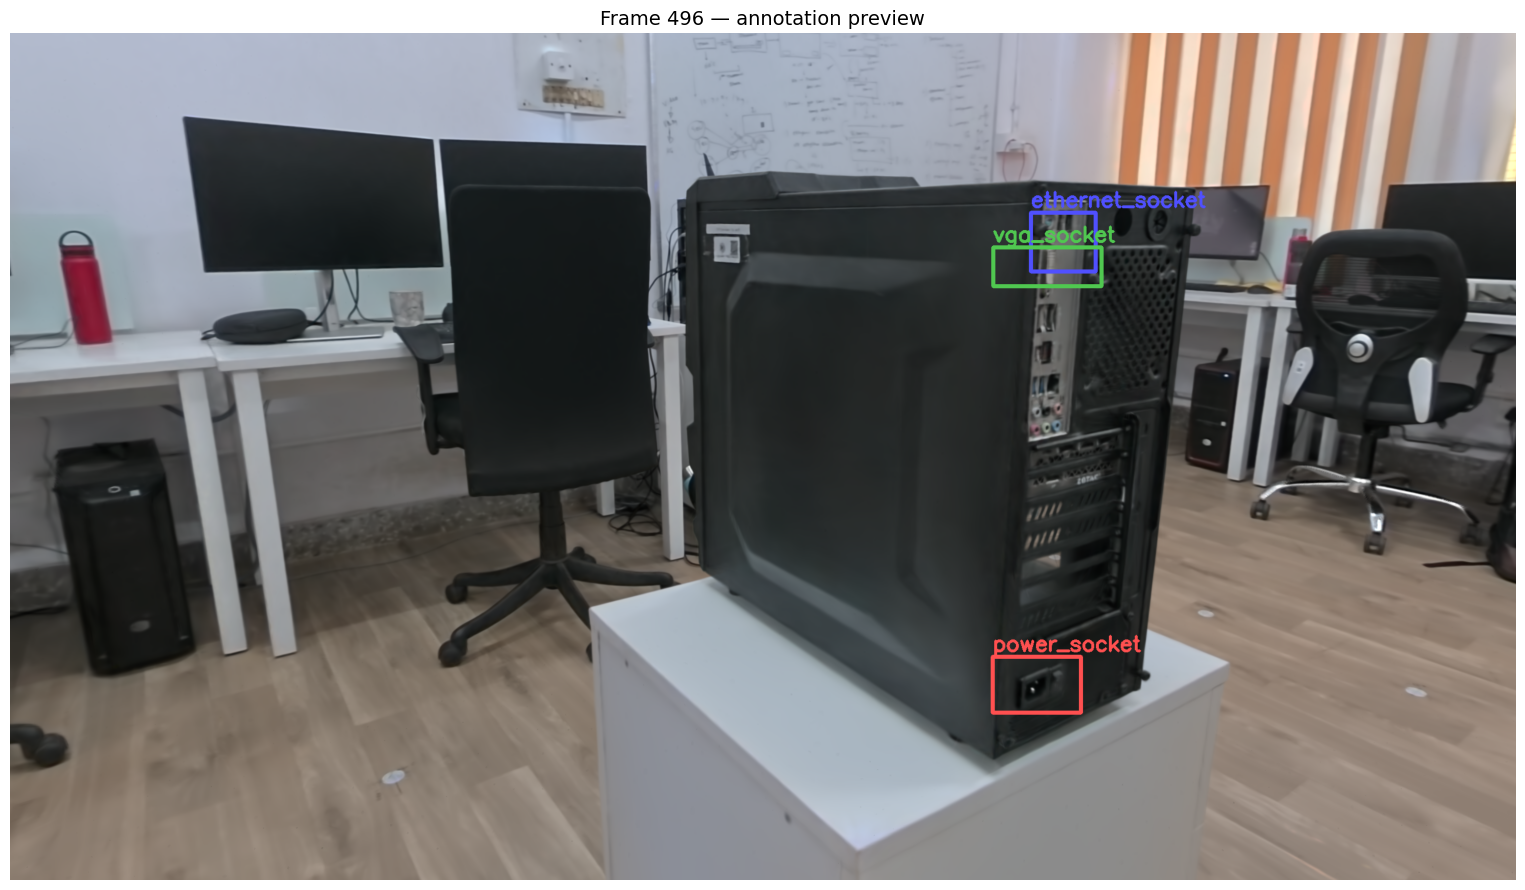

▲ Check that all 3 boxes are tightly around their ports in frame 496
  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.


In [3]:
# ── Cell 4: Preview annotations on frames 471 & 496 ──────────────────────────
# This lets you verify that the bboxes are correct before running the pipeline.
# If a box is in the wrong place, edit the coordinates in Cell 2 (semantic.py)
# and re-run Cells 2, 3, 4, 5.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import src.config as cfg
from src.semantic import ENTITY_ANNOTATIONS

colors = {
    "power_socket":    (255, 80, 80),
    "ethernet_socket": (80, 80, 255),
    "vga_socket":      (80, 200, 80),
}

for frame_idx in [471, 496]:
    img_path = Path(cfg.DATA_DIR) / f"frame_{frame_idx:06d}.png"
    if not img_path.exists():
        print(f"[SKIP] {img_path} not found")
        continue
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    vis = img_rgb.copy()
    for entity, ann_dict in ENTITY_ANNOTATIONS.items():
        if frame_idx in ann_dict:
            x1, y1, x2, y2 = ann_dict[frame_idx]
            c = colors.get(entity, (200, 200, 0))
            cv2.rectangle(vis, (x1, y1), (x2, y2), c, 5)
            cv2.putText(vis, entity, (x1, max(y1-10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, c, 3)
    plt.figure(figsize=(18, 9))
    plt.imshow(vis)
    plt.title(f"Frame {frame_idx} — annotation preview", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"▲ Check that all 3 boxes are tightly around their ports in frame {frame_idx}")
    print(f"  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.")

In [8]:
# ── PASTE THIS AS A NEW CELL — run it, then re-run Cell 5 ──────────────────
# Fixes SyntaxError in pose_estimation.py and utils.py caused by
# quote-escaping bugs in the original Cell 2 write_text() calls.

import base64
from pathlib import Path

SRC = Path("/content/project/src")

_pose_b64 = "IiIiCnBvc2VfZXN0aW1hdGlvbi5weSDigJQgZml4ZWQgdmVyc2lvbiAobm8gbmVzdGVkIGYtc3RyaW5nIHF1b3RlIGlzc3VlcykKIiIiCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gaXRlcnRvb2xzIGltcG9ydCBjb21iaW5hdGlvbnMKZnJvbSAuIGltcG9ydCBjb25maWcKZnJvbSAuZGF0YV9sb2FkZXIgaW1wb3J0IGdldF9wcm9qZWN0aW9uX21hdHJpeApmcm9tIC5zZW1hbnRpYyBpbXBvcnQgKAogICAgZ2V0X2Fubm90YXRpb25zLCBnZXRfZW50aXR5X25hbWVzLCBnZXRfcm9pX2NlbnRlciwKICAgIGdldF9yb2lfcG9pbnRzLCBnZXRfYW5ub3RhdGVkX2ZyYW1lcwopCgpERVBUSF9QUklPUlMgPSB7CiAgICAidmdhX3NvY2tldCI6ICAgICAgIDAuMDA2LAogICAgImV0aGVybmV0X3NvY2tldCI6ICAwLjAwNiwKICAgICJwb3dlcl9zb2NrZXQiOiAgICAgMC4wMDYsCn0KCgpkZWYgdHJpYW5ndWxhdGVfcG9pbnRfbXVsdGl2aWV3KHBvaW50XzJkX3Blcl92aWV3LCBLLCBwb3Nlcyk6CiAgICBmcmFtZV9pbmRpY2VzID0gbGlzdChwb2ludF8yZF9wZXJfdmlldy5rZXlzKCkpCiAgICBpZiBsZW4oZnJhbWVfaW5kaWNlcykgPCAyOgogICAgICAgIHJldHVybiBOb25lCiAgICBBID0gW10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBQID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeF0pCiAgICAgICAgdSwgdiA9IHBvaW50XzJkX3Blcl92aWV3W2lkeF0KICAgICAgICBBLmFwcGVuZCh1ICogUFsyLCA6XSAtIFBbMCwgOl0pCiAgICAgICAgQS5hcHBlbmQodiAqIFBbMiwgOl0gLSBQWzEsIDpdKQogICAgQSA9IG5wLmFycmF5KEEpCiAgICBfLCBfLCBWdCA9IG5wLmxpbmFsZy5zdmQoQSkKICAgIFggPSBWdFstMV0KICAgIFggPSBYWzozXSAvIFhbM10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBwb3NlX3cyYyA9IG5wLmxpbmFsZy5pbnYocG9zZXNbaWR4XSkKICAgICAgICBwdF9jYW0gPSBwb3NlX3cyY1s6MywgOjNdIEAgWCArIHBvc2VfdzJjWzozLCAzXQogICAgICAgIGlmIHB0X2NhbVsyXSA8PSAwOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIFgKCgpkZWYgdHJpYW5ndWxhdGVfcm9pX211bHRpdmlldyhlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgbl9ncmlkX3BvaW50cz00MDApOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICBwcmludCgiICBbV0FSTl0gTmVlZCA+PTIgdmlld3MgZm9yICVzLCBnb3QgJWQiICUgKGVudGl0eV9uYW1lLCBsZW4oZnJhbWVfaW5kaWNlcykpKQogICAgICAgIHJldHVybiBucC56ZXJvcygoMCwgMykpCgogICAgYWxsX3BvaW50cyA9IFtdCiAgICBuX3NpZGUgPSBpbnQobnAuc3FydChuX2dyaWRfcG9pbnRzKSkKICAgIHRzID0gbnAubGluc3BhY2UoMC4wNSwgMC45NSwgbl9zaWRlKQoKICAgIGZvciBpZHgxLCBpZHgyIGluIGNvbWJpbmF0aW9ucyhmcmFtZV9pbmRpY2VzLCAyKToKICAgICAgICBpZiBpZHgxIG5vdCBpbiBwb3NlcyBvciBpZHgyIG5vdCBpbiBwb3NlczoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBiYm94MSA9IGVudGl0eV9hbm5baWR4MV0KICAgICAgICBiYm94MiA9IGVudGl0eV9hbm5baWR4Ml0KICAgICAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgICAgICBQMiA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgyXSkKICAgICAgICB3MmMxID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgxXSkKICAgICAgICB3MmMyID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgyXSkKCiAgICAgICAgZm9yIHR5IGluIHRzOgogICAgICAgICAgICBmb3IgdHggaW4gdHM6CiAgICAgICAgICAgICAgICB1MSA9IGJib3gxWzBdICsgdHggKiAoYmJveDFbMl0gLSBiYm94MVswXSkKICAgICAgICAgICAgICAgIHYxID0gYmJveDFbMV0gKyB0eSAqIChiYm94MVszXSAtIGJib3gxWzFdKQogICAgICAgICAgICAgICAgdTIgPSBiYm94MlswXSArIHR4ICogKGJib3gyWzJdIC0gYmJveDJbMF0pCiAgICAgICAgICAgICAgICB2MiA9IGJib3gyWzFdICsgdHkgKiAoYmJveDJbM10gLSBiYm94MlsxXSkKICAgICAgICAgICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICAgICAgICAgIFAxLCBQMiwKICAgICAgICAgICAgICAgICAgICBucC5hcnJheShbW3UxLCB2MV1dLCBkdHlwZT1ucC5mbG9hdDY0KS5ULAogICAgICAgICAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIHB0M2QgPSAocHRzNGRbOjNdIC8gcHRzNGRbMzpdKS5mbGF0dGVuKCkKICAgICAgICAgICAgICAgIHoxID0gKHcyYzFbOjMsIDozXSBAIHB0M2QgKyB3MmMxWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIHoyID0gKHcyYzJbOjMsIDozXSBAIHB0M2QgKyB3MmMyWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIGlmIHoxID4gMCBhbmQgejIgPiAwOgogICAgICAgICAgICAgICAgICAgIHAxaCA9IFAxIEAgbnAuYXBwZW5kKHB0M2QsIDEpCiAgICAgICAgICAgICAgICAgICAgcDJoID0gUDIgQCBucC5hcHBlbmQocHQzZCwgMSkKICAgICAgICAgICAgICAgICAgICBlMSAgPSBucC5saW5hbGcubm9ybShwMWhbOjJdL3AxaFsyXSAtIFt1MSwgdjFdKQogICAgICAgICAgICAgICAgICAgIGUyICA9IG5wLmxpbmFsZy5ub3JtKHAyaFs6Ml0vcDJoWzJdIC0gW3UyLCB2Ml0pCiAgICAgICAgICAgICAgICAgICAgaWYgZTEgPCA1MCBhbmQgZTIgPCA1MDoKICAgICAgICAgICAgICAgICAgICAgICAgYWxsX3BvaW50cy5hcHBlbmQocHQzZCkKCiAgICBpZiBsZW4oYWxsX3BvaW50cykgPT0gMDoKICAgICAgICBwcmludCgiICBbV0FSTl0gTm8gM0QgcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICByZXR1cm4gbnAuemVyb3MoKDAsIDMpKQoKICAgIHB0cyA9IF9yZW1vdmVfb3V0bGllcnNfbWFkKG5wLmFycmF5KGFsbF9wb2ludHMpKQogICAgcHJpbnQoIiAgJXM6IHRyaWFuZ3VsYXRlZCAlZCAzRCBwb2ludHMiICUgKGVudGl0eV9uYW1lLCBsZW4ocHRzKSkpCiAgICByZXR1cm4gcHRzCgoKZGVmIF9yZW1vdmVfb3V0bGllcnNfbWFkKHBvaW50cywgdGhyZXNob2xkPTMuMCk6CiAgICBpZiBsZW4ocG9pbnRzKSA8IDU6CiAgICAgICAgcmV0dXJuIHBvaW50cwogICAgbWVkaWFuICAgPSBucC5tZWRpYW4ocG9pbnRzLCBheGlzPTApCiAgICBkaWZmcyAgICA9IG5wLmxpbmFsZy5ub3JtKHBvaW50cyAtIG1lZGlhbiwgYXhpcz0xKQogICAgbWVkX2RpZmYgPSBucC5tZWRpYW4oZGlmZnMpCiAgICBtYWQgICAgICA9IDEuNDgyNiAqIG1lZF9kaWZmCiAgICBpZiBtYWQgPCAxZS0xMDoKICAgICAgICByZXR1cm4gcG9pbnRzCiAgICByZXR1cm4gcG9pbnRzW2RpZmZzIDwgdGhyZXNob2xkICogbWFkXQoKCmRlZiBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMpOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICByZXR1cm4gTm9uZSwgTm9uZSwgTm9uZQogICAgaWR4MSwgaWR4MiA9IGZyYW1lX2luZGljZXNbMF0sIGZyYW1lX2luZGljZXNbMV0KICAgIGJib3gxID0gZW50aXR5X2FubltpZHgxXQogICAgYmJveDIgPSBlbnRpdHlfYW5uW2lkeDJdCiAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgIFAyID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeDJdKQoKICAgIGRlZiB0cmkodTEsIHYxLCB1MiwgdjIpOgogICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICBQMSwgUDIsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTEsIHYxXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICApCiAgICAgICAgcmV0dXJuIChwdHM0ZFs6M10gLyBwdHM0ZFszOl0pLmZsYXR0ZW4oKQoKICAgIHRsID0gdHJpKGJib3gxWzBdLCBiYm94MVsxXSwgYmJveDJbMF0sIGJib3gyWzFdKQogICAgdHIgPSB0cmkoYmJveDFbMl0sIGJib3gxWzFdLCBiYm94MlsyXSwgYmJveDJbMV0pCiAgICBibCA9IHRyaShiYm94MVswXSwgYmJveDFbM10sIGJib3gyWzBdLCBiYm94MlszXSkKICAgIGJyID0gdHJpKGJib3gxWzJdLCBiYm94MVszXSwgYmJveDJbMl0sIGJib3gyWzNdKQoKICAgIGFjcm9zc19kaXIgID0gKCh0ciAtIHRsKSArIChiciAtIGJsKSkgLyAyLjAKICAgIGFjcm9zc19kaXIgLz0gbnAubGluYWxnLm5vcm0oYWNyb3NzX2RpcikgKyAxZS0xMgogICAgZG93bl9kaXIgICAgPSAoKGJsIC0gdGwpICsgKGJyIC0gdHIpKSAvIDIuMAogICAgZG93bl9kaXIgICAvPSBucC5saW5hbGcubm9ybShkb3duX2RpcikgKyAxZS0xMgogICAgbm9ybWFsX2RpciAgPSBucC5jcm9zcyhhY3Jvc3NfZGlyLCBkb3duX2RpcikKICAgIG5vcm1hbF9kaXIgLz0gbnAubGluYWxnLm5vcm0obm9ybWFsX2RpcikgKyAxZS0xMgoKICAgIHJldHVybiBkb3duX2RpciwgYWNyb3NzX2Rpciwgbm9ybWFsX2RpcgoKCmRlZiBmaXRfb2JiX3dpdGhfZGVwdGgocG9pbnRzXzNkLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKToKICAgIGlmIGxlbihwb2ludHNfM2QpIDwgMzoKICAgICAgICBwcmludCgiICBbV0FSTl0gVG9vIGZldyBwb2ludHMgZm9yIE9CQiBmaXR0aW5nIikKICAgICAgICByZXR1cm4gTm9uZQoKICAgIGNlbnRlciAgID0gbnAubWVhbihwb2ludHNfM2QsIGF4aXM9MCkKICAgIGNlbnRlcmVkID0gcG9pbnRzXzNkIC0gY2VudGVyCgogICAgZG93bl9kaXIsIGFjcm9zc19kaXIsIG5vcm1hbF9kaXIgPSBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKAogICAgICAgIGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMKICAgICkKICAgIGlmIG5vcm1hbF9kaXIgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQoKICAgIHJvdzAgPSBub3JtYWxfZGlyLmNvcHkoKQogICAgaWYgcm93MFsxXSA8IDA6CiAgICAgICAgcm93MCA9IC1yb3cwCiAgICByb3cyID0gYWNyb3NzX2Rpci5jb3B5KCkKICAgIGlmIHJvdzJbMF0gPCAwOgogICAgICAgIHJvdzIgPSAtcm93MgogICAgcm93MSAgPSBucC5jcm9zcyhyb3cyLCByb3cwKQogICAgcm93MSAvPSBucC5saW5hbGcubm9ybShyb3cxKSArIDFlLTEyCiAgICByb3cwICA9IG5wLmNyb3NzKHJvdzEsIHJvdzIpCiAgICByb3cwIC89IG5wLmxpbmFsZy5ub3JtKHJvdzApICsgMWUtMTIKICAgIFIgPSBucC5hcnJheShbcm93MCwgcm93MSwgcm93Ml0pCgogICAgXywgZWlnZW52ZWN0b3JzID0gbnAubGluYWxnLmVpZ2gobnAuY292KGNlbnRlcmVkLlQpKQogICAgcHJvamVjdGVkX3BjYSAgID0gY2VudGVyZWQgQCBlaWdlbnZlY3RvcnMKICAgIHBjYV9zcHJlYWRzICAgICA9IChwcm9qZWN0ZWRfcGNhLm1heChheGlzPTApIC0gcHJvamVjdGVkX3BjYS5taW4oYXhpcz0wKSkgLyAyLjAKCiAgICBkZXB0aF9wcmlvciA9IERFUFRIX1BSSU9SUy5nZXQoZW50aXR5X25hbWUsIDAuMDA2KQogICAgZXh0ZW50ICAgICAgPSBucC56ZXJvcygzKQogICAgZXh0ZW50WzBdICAgPSBwY2Ffc3ByZWFkc1syXQogICAgZXh0ZW50WzFdICAgPSBwY2Ffc3ByZWFkc1sxXQogICAgZXh0ZW50WzJdICAgPSBkZXB0aF9wcmlvcgogICAgaWYgZXh0ZW50WzFdIDwgZGVwdGhfcHJpb3IgLyAyLjA6CiAgICAgICAgZXh0ZW50WzFdID0gZGVwdGhfcHJpb3IKCiAgICBwcm9qZWN0ZWQgICAgID0gY2VudGVyZWQgQCBSLlQKICAgIGNlbnRlcl9vZmZzZXQgPSBSLlQgQCAoKHByb2plY3RlZC5taW4oYXhpcz0wKSArIHByb2plY3RlZC5tYXgoYXhpcz0wKSkgLyAyLjApCiAgICBjZW50ZXIgICAgICAgID0gY2VudGVyICsgY2VudGVyX29mZnNldAoKICAgIHJldHVybiB7CiAgICAgICAgImNlbnRlciI6ICAgY2VudGVyLnRvbGlzdCgpLAogICAgICAgICJleHRlbnQiOiAgIGV4dGVudC50b2xpc3QoKSwKICAgICAgICAicm90YXRpb24iOiBSLnRvbGlzdCgpCiAgICB9CgoKZGVmIGVzdGltYXRlX2FsbF9wb3Nlcyhhbm5vdGF0aW9ucywgSywgcG9zZXMsIG5fZ3JpZF9wb2ludHM9NDAwKToKICAgIHByaW50KCJcbj09PSBPQkIgUG9zZSBFc3RpbWF0aW9uID09PSIpCiAgICByZXN1bHRzID0gW10KICAgIGZvciBlbnRpdHlfbmFtZSBpbiBnZXRfZW50aXR5X25hbWVzKCk6CiAgICAgICAgcHJpbnQoIlxuICBQcm9jZXNzaW5nOiAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICBwdHMgPSB0cmlhbmd1bGF0ZV9yb2lfbXVsdGl2aWV3KAogICAgICAgICAgICBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLCBuX2dyaWRfcG9pbnRzCiAgICAgICAgKQogICAgICAgIGlmIGxlbihwdHMpIDwgMzoKICAgICAgICAgICAgcHJpbnQoIiAgW1NLSVBdIE5vdCBlbm91Z2ggcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICAgICAgY29udGludWUKICAgICAgICBvYmIgPSBmaXRfb2JiX3dpdGhfZGVwdGgocHRzLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKQogICAgICAgIGlmIG9iYiBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHJlc3VsdHMuYXBwZW5kKHsiZW50aXR5IjogZW50aXR5X25hbWUsICJvYmIiOiBvYmJ9KQogICAgICAgIGMgPSBbcm91bmQodiwgNCkgZm9yIHYgaW4gb2JiWyJjZW50ZXIiXV0KICAgICAgICBlID0gW3JvdW5kKHYsIDQpIGZvciB2IGluIG9iYlsiZXh0ZW50Il1dCiAgICAgICAgcHJpbnQoIiAgICBDZW50ZXI6ICVzIiAlIGMpCiAgICAgICAgcHJpbnQoIiAgICBFeHRlbnQ6ICVzIiAlIGUpCiAgICByZXR1cm4gcmVzdWx0cwoKCmRlZiB2YWxpZGF0ZV93aXRoX3Byb2plY3Rpb24ocmVzdWx0cywgaW1hZ2VzLCBLLCBwb3Nlcyk6CiAgICBpbXBvcnQgb3MKICAgIGltcG9ydCBjdjIKICAgIGZyb20gLnV0aWxzIGltcG9ydCBwcm9qZWN0X29iYl90b19pbWFnZSwgZHJhd19vYmJfb25faW1hZ2UKCiAgICBjb2xvcnMgPSB7CiAgICAgICAgInBvd2VyX3NvY2tldCI6ICAgICgwLCAwLCAyNTUpLAogICAgICAgICJldGhlcm5ldF9zb2NrZXQiOiAoMjU1LCAwLCAwKSwKICAgICAgICAidmdhX3NvY2tldCI6ICAgICAgKDAsIDI1NSwgMCksCiAgICB9CiAgICBmb3IgaWR4IGluIFs0NzEsIDQ5NiwgNTE1XToKICAgICAgICBpZiBpZHggbm90IGluIGltYWdlcyBvciBpZHggbm90IGluIHBvc2VzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHZpcyA9IGltYWdlc1tpZHhdLmNvcHkoKQogICAgICAgIGZvciByZXMgaW4gcmVzdWx0czoKICAgICAgICAgICAgY29sb3IgICAgICA9IGNvbG9ycy5nZXQocmVzWyJlbnRpdHkiXSwgKDAsIDI1NSwgMjU1KSkKICAgICAgICAgICAgY29ybmVyc18yZCA9IHByb2plY3Rfb2JiX3RvX2ltYWdlKHJlc1sib2JiIl0sIEssIHBvc2VzW2lkeF0pCiAgICAgICAgICAgIHZpcyAgICAgICAgPSBkcmF3X29iYl9vbl9pbWFnZSh2aXMsIGNvcm5lcnNfMmQsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBsYWJlbD1yZXNbImVudGl0eSJdLCBjb2xvcj1jb2xvcikKICAgICAgICBvdXQgPSBvcy5wYXRoLmpvaW4oY29uZmlnLk9VVFBVVF9ESVIsICJkZXRlY3Rpb25zIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgIm9iYl9wcm9qZWN0aW9uXyUwNmQucG5nIiAlIGlkeCkKICAgICAgICBjdjIuaW13cml0ZShvdXQsIHZpcykKICAgICAgICBwcmludCgiICBTYXZlZCBPQkIgcHJvamVjdGlvbjogJXMiICUgb3V0KQo="
_utils_b64 = "IiIiCnV0aWxzLnB5IOKAlCB2aXN1YWxpemF0aW9uIGFuZCBJL08gdXRpbGl0aWVzIChmaXhlZCkKIiIiCmltcG9ydCBqc29uCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCgoKZGVmIHByb2plY3Rfb2JiX3RvX2ltYWdlKG9iYiwgSywgcG9zZV9jMncpOgogICAgY2VudGVyICA9IG5wLmFycmF5KG9iYlsiY2VudGVyIl0pCiAgICBleHRlbnQgID0gbnAuYXJyYXkob2JiWyJleHRlbnQiXSkKICAgIFJfb2JiICAgPSBucC5hcnJheShvYmJbInJvdGF0aW9uIl0pCiAgICBzaWducyAgID0gbnAuYXJyYXkoWwogICAgICAgIFstMSwtMSwtMV0sWy0xLC0xLDFdLFstMSwxLC0xXSxbLTEsMSwxXSwKICAgICAgICBbIDEsLTEsLTFdLFsgMSwtMSwxXSxbIDEsMSwtMV0sWyAxLDEsMV0KICAgIF0sIGR0eXBlPW5wLmZsb2F0NjQpCiAgICBjb3JuZXJzX3dvcmxkID0gKFJfb2JiIEAgKHNpZ25zICogZXh0ZW50KS5UKS5UICsgY2VudGVyCiAgICBwb3NlX3cyYyAgICAgID0gbnAubGluYWxnLmludihwb3NlX2MydykKICAgIGNvcm5lcnNfY2FtICAgPSAocG9zZV93MmNbOjMsOjNdIEAgY29ybmVyc193b3JsZC5UKS5UICsgcG9zZV93MmNbOjMsM10KICAgIGNvcm5lcnNfMmQgICAgPSBucC5mdWxsKCg4LCAyKSwgbnAubmFuKQogICAgZm9yIGkgaW4gcmFuZ2UoOCk6CiAgICAgICAgaWYgY29ybmVyc19jYW1baSwyXSA+IDA6CiAgICAgICAgICAgIHB0ID0gSyBAIGNvcm5lcnNfY2FtW2ldCiAgICAgICAgICAgIGNvcm5lcnNfMmRbaV0gPSBwdFs6Ml0gLyBwdFsyXQogICAgcmV0dXJuIGNvcm5lcnNfMmQKCgpkZWYgZHJhd19vYmJfb25faW1hZ2UoaW1hZ2UsIGNvcm5lcnNfMmQsIGxhYmVsPSIiLCBjb2xvcj0oMCwyNTUsMCksIHRoaWNrbmVzcz0yKToKICAgIGlmIGNvcm5lcnNfMmQgaXMgTm9uZToKICAgICAgICByZXR1cm4gaW1hZ2UKICAgIHZpcyAgID0gaW1hZ2UuY29weSgpCiAgICBwdHMgICA9IGNvcm5lcnNfMmQuYXN0eXBlKGludCkKICAgIGVkZ2VzID0gWygwLDEpLCgwLDIpLCgwLDQpLCgxLDMpLCgxLDUpLCgyLDMpLAogICAgICAgICAgICAgKDIsNiksKDMsNyksKDQsNSksKDQsNiksKDUsNyksKDYsNyldCiAgICBmb3IgaSwgaiBpbiBlZGdlczoKICAgICAgICBpZiBub3QgKG5wLmlzbmFuKGNvcm5lcnNfMmRbaV0pLmFueSgpIG9yIG5wLmlzbmFuKGNvcm5lcnNfMmRbal0pLmFueSgpKToKICAgICAgICAgICAgY3YyLmxpbmUodmlzLCB0dXBsZShwdHNbaV0pLCB0dXBsZShwdHNbal0pLCBjb2xvciwgdGhpY2tuZXNzKQogICAgaWYgbGFiZWw6CiAgICAgICAgdmFsaWQgPSBwdHNbfm5wLmlzbmFuKGNvcm5lcnNfMmQpLmFueShheGlzPTEpXQogICAgICAgIGlmIGxlbih2YWxpZCkgPiAwOgogICAgICAgICAgICB0bCA9IHZhbGlkLm1pbihheGlzPTApCiAgICAgICAgICAgIGN2Mi5wdXRUZXh0KHZpcywgbGFiZWwsIHR1cGxlKHRsIC0gWzAsIDEwXSksCiAgICAgICAgICAgICAgICAgICAgICAgIGN2Mi5GT05UX0hFUlNIRVlfU0lNUExFWCwgMC44LCBjb2xvciwgMikKICAgIHJldHVybiB2aXMKCgpkZWYgZHJhd19iYm94X29uX2ltYWdlKGltYWdlLCBiYm94LCBsYWJlbD0iIiwgY29sb3I9KDAsMjU1LDApLCB0aGlja25lc3M9Mik6CiAgICB2aXMgPSBpbWFnZS5jb3B5KCkKICAgIHgxLCB5MSwgeDIsIHkyID0gW2ludCh2KSBmb3IgdiBpbiBiYm94XQogICAgY3YyLnJlY3RhbmdsZSh2aXMsICh4MSwgeTEpLCAoeDIsIHkyKSwgY29sb3IsIHRoaWNrbmVzcykKICAgIGlmIGxhYmVsOgogICAgICAgIGN2Mi5wdXRUZXh0KHZpcywgbGFiZWwsICh4MSwgeTEgLSAxMCksCiAgICAgICAgICAgICAgICAgICAgY3YyLkZPTlRfSEVSU0hFWV9TSU1QTEVYLCAwLjcsIGNvbG9yLCAyKQogICAgcmV0dXJuIHZpcwoKCmRlZiBzYXZlX2Fuc3dlcnNfanNvbihlbnRpdGllcywgb3V0cHV0X3BhdGgpOgogICAgb3V0cHV0ID0gW10KICAgIGZvciBlbnQgaW4gZW50aXRpZXM6CiAgICAgICAgb3V0cHV0LmFwcGVuZCh7CiAgICAgICAgICAgICJlbnRpdHkiOiBlbnRbImVudGl0eSJdLAogICAgICAgICAgICAib2JiIjogewogICAgICAgICAgICAgICAgImNlbnRlciI6ICAgW2Zsb2F0KHYpIGZvciB2IGluIGVudFsib2JiIl1bImNlbnRlciJdXSwKICAgICAgICAgICAgICAgICJleHRlbnQiOiAgIFtmbG9hdCh2KSBmb3IgdiBpbiBlbnRbIm9iYiJdWyJleHRlbnQiXV0sCiAgICAgICAgICAgICAgICAicm90YXRpb24iOiBbW2Zsb2F0KHYpIGZvciB2IGluIHJvd10KICAgICAgICAgICAgICAgICAgICAgICAgICAgICBmb3Igcm93IGluIGVudFsib2JiIl1bInJvdGF0aW9uIl1dCiAgICAgICAgICAgIH0KICAgICAgICB9KQogICAgd2l0aCBvcGVuKG91dHB1dF9wYXRoLCAidyIpIGFzIGY6CiAgICAgICAganNvbi5kdW1wKG91dHB1dCwgZiwgaW5kZW50PTIpCiAgICBwcmludCgiICBTYXZlZCBhbnN3ZXJzIHRvICVzIiAlIG91dHB1dF9wYXRoKQoKCmRlZiB2YWxpZGF0ZV9hZ2FpbnN0X3NhbXBsZShhbnN3ZXJzLCBzYW1wbGVfYW5zd2Vycyk6CiAgICBzYW1wbGVfdmdhID0gbmV4dCgoc1sib2JiIl0gZm9yIHMgaW4gc2FtcGxlX2Fuc3dlcnMKICAgICAgICAgICAgICAgICAgICAgICBpZiBzWyJlbnRpdHkiXSA9PSAidmdhX3NvY2tldCIpLCBOb25lKQogICAgb3VyX3ZnYSAgICA9IG5leHQoKGFbIm9iYiJdIGZvciBhIGluIGFuc3dlcnMKICAgICAgICAgICAgICAgICAgICAgICBpZiBhWyJlbnRpdHkiXSA9PSAidmdhX3NvY2tldCIpLCBOb25lKQogICAgaWYgc2FtcGxlX3ZnYSBpcyBOb25lOgogICAgICAgIHByaW50KCIgIFtJTkZPXSBObyBWR0Egc29ja2V0IGluIHNhbXBsZSBhbnN3ZXJzIikKICAgICAgICByZXR1cm4KICAgIGlmIG91cl92Z2EgaXMgTm9uZToKICAgICAgICBwcmludCgiICBbSU5GT10gTm8gVkdBIHNvY2tldCBwcmVkaWN0ZWQiKQogICAgICAgIHJldHVybgoKICAgIGNfcyAgPSBucC5hcnJheShzYW1wbGVfdmdhWyJjZW50ZXIiXSkKICAgIGNfbyAgPSBucC5hcnJheShvdXJfdmdhWyJjZW50ZXIiXSkKICAgIGRpc3QgPSBucC5saW5hbGcubm9ybShjX3MgLSBjX28pCiAgICBwcmludCgiXG4gID09PSBWR0EgU29ja2V0IFZhbGlkYXRpb24gPT09IikKICAgIHByaW50KCIgIENlbnRlciBkaXN0YW5jZTogJS40ZiBtICAoJS4xZiBtbSkiICUgKGRpc3QsIGRpc3QgKiAxMDAwKSkKICAgIHByaW50KCIgICAgR1Q6ICAgJXMiICUgbnAucm91bmQoY19zLCA0KS50b2xpc3QoKSkKICAgIHByaW50KCIgICAgUHJlZDogJXMiICUgbnAucm91bmQoY19vLCA0KS50b2xpc3QoKSkKCiAgICBlX3MgPSBucC5zb3J0KG5wLmFycmF5KHNhbXBsZV92Z2FbImV4dGVudCJdKSlbOjotMV0KICAgIGVfbyA9IG5wLnNvcnQobnAuYXJyYXkob3VyX3ZnYVsiZXh0ZW50Il0pKVs6Oi0xXQogICAgcHJpbnQoIiAgRXh0ZW50cyBzb3J0ZWQg4oCUIEdUOiAlcyAgUHJlZDogJXMiICUgKAogICAgICAgICAgbnAucm91bmQoZV9zLDQpLnRvbGlzdCgpLCBucC5yb3VuZChlX28sNCkudG9saXN0KCkpKQoKICAgIFJfcyA9IG5wLmFycmF5KHNhbXBsZV92Z2FbInJvdGF0aW9uIl0pCiAgICBSX28gPSBucC5hcnJheShvdXJfdmdhWyJyb3RhdGlvbiJdKQogICAgdHJ5OgogICAgICAgIHRyYWNlID0gbnAuY2xpcChucC50cmFjZShSX28gQCBSX3MuVCksIC0xLjAsIDMuMCkKICAgICAgICBhbmdsZSA9IG5wLmRlZ3JlZXMobnAuYXJjY29zKG5wLmNsaXAoKHRyYWNlIC0gMSkgLyAyLCAtMSwgMSkpKQogICAgICAgIHByaW50KCIgIFJvdGF0aW9uIGVycm9yOiAlLjFmIGRlZyIgJSBhbmdsZSkKICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZToKICAgICAgICBwcmludCgiICBSb3RhdGlvbiBlcnJvciBjb21wdXRhdGlvbiBmYWlsZWQ6ICVzIiAlIGUpCgogICAgaWYgZGlzdCA8IDAuMDU6CiAgICAgICAgcHJpbnQoIiAgT0sg4oCUIGNlbnRlciBlcnJvciA8IDUgY20iKQogICAgZWxpZiBkaXN0IDwgMC4xMDoKICAgICAgICBwcmludCgiICBXQVJOSU5HIOKAlCBjZW50ZXIgZXJyb3IgPCAxMCBjbSIpCiAgICBlbHNlOgogICAgICAgIHByaW50KCIgIEVSUk9SIOKAlCBsYXJnZSBlcnJvciwgY2hlY2sgYmJveCBjb29yZHMgaW4gc2VtYW50aWMucHkiKQo="

(SRC / "pose_estimation.py").write_bytes(base64.b64decode(_pose_b64))
(SRC / "utils.py").write_bytes(base64.b64decode(_utils_b64))

# Clear any cached imports so Python reloads the fixed modules
import sys
for mod in list(sys.modules.keys()):
    if mod.startswith("src"):
        del sys.modules[mod]

print("pose_estimation.py  fixed")
print("utils.py            fixed")
print("Now re-run Cell 5")

pose_estimation.py  fixed
utils.py            fixed
Now re-run Cell 5


In [5]:
# ── FIX CELL: Run this to patch pose_estimation.py, then re-run Cell 5 ─────
import base64
from pathlib import Path

_src = base64.b64decode('IiIiCnBvc2VfZXN0aW1hdGlvbi5weSDigJQgZml4ZWQgdmVyc2lvbiAobm8gbmVzdGVkIGYtc3RyaW5nIHF1b3RlIGlzc3VlcykKIiIiCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gaXRlcnRvb2xzIGltcG9ydCBjb21iaW5hdGlvbnMKZnJvbSAuIGltcG9ydCBjb25maWcKZnJvbSAuZGF0YV9sb2FkZXIgaW1wb3J0IGdldF9wcm9qZWN0aW9uX21hdHJpeApmcm9tIC5zZW1hbnRpYyBpbXBvcnQgKAogICAgZ2V0X2Fubm90YXRpb25zLCBnZXRfZW50aXR5X25hbWVzLCBnZXRfcm9pX2NlbnRlciwKICAgIGdldF9yb2lfcG9pbnRzLCBnZXRfYW5ub3RhdGVkX2ZyYW1lcwopCgpERVBUSF9QUklPUlMgPSB7CiAgICAidmdhX3NvY2tldCI6ICAgICAgIDAuMDA2LAogICAgImV0aGVybmV0X3NvY2tldCI6ICAwLjAwNiwKICAgICJwb3dlcl9zb2NrZXQiOiAgICAgMC4wMDYsCn0KCgpkZWYgdHJpYW5ndWxhdGVfcG9pbnRfbXVsdGl2aWV3KHBvaW50XzJkX3Blcl92aWV3LCBLLCBwb3Nlcyk6CiAgICBmcmFtZV9pbmRpY2VzID0gbGlzdChwb2ludF8yZF9wZXJfdmlldy5rZXlzKCkpCiAgICBpZiBsZW4oZnJhbWVfaW5kaWNlcykgPCAyOgogICAgICAgIHJldHVybiBOb25lCiAgICBBID0gW10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBQID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeF0pCiAgICAgICAgdSwgdiA9IHBvaW50XzJkX3Blcl92aWV3W2lkeF0KICAgICAgICBBLmFwcGVuZCh1ICogUFsyLCA6XSAtIFBbMCwgOl0pCiAgICAgICAgQS5hcHBlbmQodiAqIFBbMiwgOl0gLSBQWzEsIDpdKQogICAgQSA9IG5wLmFycmF5KEEpCiAgICBfLCBfLCBWdCA9IG5wLmxpbmFsZy5zdmQoQSkKICAgIFggPSBWdFstMV0KICAgIFggPSBYWzozXSAvIFhbM10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBwb3NlX3cyYyA9IG5wLmxpbmFsZy5pbnYocG9zZXNbaWR4XSkKICAgICAgICBwdF9jYW0gPSBwb3NlX3cyY1s6MywgOjNdIEAgWCArIHBvc2VfdzJjWzozLCAzXQogICAgICAgIGlmIHB0X2NhbVsyXSA8PSAwOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIFgKCgpkZWYgdHJpYW5ndWxhdGVfcm9pX211bHRpdmlldyhlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgbl9ncmlkX3BvaW50cz00MDApOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICBwcmludCgiICBbV0FSTl0gTmVlZCA+PTIgdmlld3MgZm9yICVzLCBnb3QgJWQiICUgKGVudGl0eV9uYW1lLCBsZW4oZnJhbWVfaW5kaWNlcykpKQogICAgICAgIHJldHVybiBucC56ZXJvcygoMCwgMykpCgogICAgYWxsX3BvaW50cyA9IFtdCiAgICBuX3NpZGUgPSBpbnQobnAuc3FydChuX2dyaWRfcG9pbnRzKSkKICAgIHRzID0gbnAubGluc3BhY2UoMC4wNSwgMC45NSwgbl9zaWRlKQoKICAgIGZvciBpZHgxLCBpZHgyIGluIGNvbWJpbmF0aW9ucyhmcmFtZV9pbmRpY2VzLCAyKToKICAgICAgICBpZiBpZHgxIG5vdCBpbiBwb3NlcyBvciBpZHgyIG5vdCBpbiBwb3NlczoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBiYm94MSA9IGVudGl0eV9hbm5baWR4MV0KICAgICAgICBiYm94MiA9IGVudGl0eV9hbm5baWR4Ml0KICAgICAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgICAgICBQMiA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgyXSkKICAgICAgICB3MmMxID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgxXSkKICAgICAgICB3MmMyID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgyXSkKCiAgICAgICAgZm9yIHR5IGluIHRzOgogICAgICAgICAgICBmb3IgdHggaW4gdHM6CiAgICAgICAgICAgICAgICB1MSA9IGJib3gxWzBdICsgdHggKiAoYmJveDFbMl0gLSBiYm94MVswXSkKICAgICAgICAgICAgICAgIHYxID0gYmJveDFbMV0gKyB0eSAqIChiYm94MVszXSAtIGJib3gxWzFdKQogICAgICAgICAgICAgICAgdTIgPSBiYm94MlswXSArIHR4ICogKGJib3gyWzJdIC0gYmJveDJbMF0pCiAgICAgICAgICAgICAgICB2MiA9IGJib3gyWzFdICsgdHkgKiAoYmJveDJbM10gLSBiYm94MlsxXSkKICAgICAgICAgICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICAgICAgICAgIFAxLCBQMiwKICAgICAgICAgICAgICAgICAgICBucC5hcnJheShbW3UxLCB2MV1dLCBkdHlwZT1ucC5mbG9hdDY0KS5ULAogICAgICAgICAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIHB0M2QgPSAocHRzNGRbOjNdIC8gcHRzNGRbMzpdKS5mbGF0dGVuKCkKICAgICAgICAgICAgICAgIHoxID0gKHcyYzFbOjMsIDozXSBAIHB0M2QgKyB3MmMxWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIHoyID0gKHcyYzJbOjMsIDozXSBAIHB0M2QgKyB3MmMyWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIGlmIHoxID4gMCBhbmQgejIgPiAwOgogICAgICAgICAgICAgICAgICAgIHAxaCA9IFAxIEAgbnAuYXBwZW5kKHB0M2QsIDEpCiAgICAgICAgICAgICAgICAgICAgcDJoID0gUDIgQCBucC5hcHBlbmQocHQzZCwgMSkKICAgICAgICAgICAgICAgICAgICBlMSAgPSBucC5saW5hbGcubm9ybShwMWhbOjJdL3AxaFsyXSAtIFt1MSwgdjFdKQogICAgICAgICAgICAgICAgICAgIGUyICA9IG5wLmxpbmFsZy5ub3JtKHAyaFs6Ml0vcDJoWzJdIC0gW3UyLCB2Ml0pCiAgICAgICAgICAgICAgICAgICAgaWYgZTEgPCA1MCBhbmQgZTIgPCA1MDoKICAgICAgICAgICAgICAgICAgICAgICAgYWxsX3BvaW50cy5hcHBlbmQocHQzZCkKCiAgICBpZiBsZW4oYWxsX3BvaW50cykgPT0gMDoKICAgICAgICBwcmludCgiICBbV0FSTl0gTm8gM0QgcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICByZXR1cm4gbnAuemVyb3MoKDAsIDMpKQoKICAgIHB0cyA9IF9yZW1vdmVfb3V0bGllcnNfbWFkKG5wLmFycmF5KGFsbF9wb2ludHMpKQogICAgcHJpbnQoIiAgJXM6IHRyaWFuZ3VsYXRlZCAlZCAzRCBwb2ludHMiICUgKGVudGl0eV9uYW1lLCBsZW4ocHRzKSkpCiAgICByZXR1cm4gcHRzCgoKZGVmIF9yZW1vdmVfb3V0bGllcnNfbWFkKHBvaW50cywgdGhyZXNob2xkPTMuMCk6CiAgICBpZiBsZW4ocG9pbnRzKSA8IDU6CiAgICAgICAgcmV0dXJuIHBvaW50cwogICAgbWVkaWFuICAgPSBucC5tZWRpYW4ocG9pbnRzLCBheGlzPTApCiAgICBkaWZmcyAgICA9IG5wLmxpbmFsZy5ub3JtKHBvaW50cyAtIG1lZGlhbiwgYXhpcz0xKQogICAgbWVkX2RpZmYgPSBucC5tZWRpYW4oZGlmZnMpCiAgICBtYWQgICAgICA9IDEuNDgyNiAqIG1lZF9kaWZmCiAgICBpZiBtYWQgPCAxZS0xMDoKICAgICAgICByZXR1cm4gcG9pbnRzCiAgICByZXR1cm4gcG9pbnRzW2RpZmZzIDwgdGhyZXNob2xkICogbWFkXQoKCmRlZiBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMpOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICByZXR1cm4gTm9uZSwgTm9uZSwgTm9uZQogICAgaWR4MSwgaWR4MiA9IGZyYW1lX2luZGljZXNbMF0sIGZyYW1lX2luZGljZXNbMV0KICAgIGJib3gxID0gZW50aXR5X2FubltpZHgxXQogICAgYmJveDIgPSBlbnRpdHlfYW5uW2lkeDJdCiAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgIFAyID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeDJdKQoKICAgIGRlZiB0cmkodTEsIHYxLCB1MiwgdjIpOgogICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICBQMSwgUDIsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTEsIHYxXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICApCiAgICAgICAgcmV0dXJuIChwdHM0ZFs6M10gLyBwdHM0ZFszOl0pLmZsYXR0ZW4oKQoKICAgIHRsID0gdHJpKGJib3gxWzBdLCBiYm94MVsxXSwgYmJveDJbMF0sIGJib3gyWzFdKQogICAgdHIgPSB0cmkoYmJveDFbMl0sIGJib3gxWzFdLCBiYm94MlsyXSwgYmJveDJbMV0pCiAgICBibCA9IHRyaShiYm94MVswXSwgYmJveDFbM10sIGJib3gyWzBdLCBiYm94MlszXSkKICAgIGJyID0gdHJpKGJib3gxWzJdLCBiYm94MVszXSwgYmJveDJbMl0sIGJib3gyWzNdKQoKICAgIGFjcm9zc19kaXIgID0gKCh0ciAtIHRsKSArIChiciAtIGJsKSkgLyAyLjAKICAgIGFjcm9zc19kaXIgLz0gbnAubGluYWxnLm5vcm0oYWNyb3NzX2RpcikgKyAxZS0xMgogICAgZG93bl9kaXIgICAgPSAoKGJsIC0gdGwpICsgKGJyIC0gdHIpKSAvIDIuMAogICAgZG93bl9kaXIgICAvPSBucC5saW5hbGcubm9ybShkb3duX2RpcikgKyAxZS0xMgogICAgbm9ybWFsX2RpciAgPSBucC5jcm9zcyhhY3Jvc3NfZGlyLCBkb3duX2RpcikKICAgIG5vcm1hbF9kaXIgLz0gbnAubGluYWxnLm5vcm0obm9ybWFsX2RpcikgKyAxZS0xMgoKICAgIHJldHVybiBkb3duX2RpciwgYWNyb3NzX2Rpciwgbm9ybWFsX2RpcgoKCmRlZiBmaXRfb2JiX3dpdGhfZGVwdGgocG9pbnRzXzNkLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKToKICAgIGlmIGxlbihwb2ludHNfM2QpIDwgMzoKICAgICAgICBwcmludCgiICBbV0FSTl0gVG9vIGZldyBwb2ludHMgZm9yIE9CQiBmaXR0aW5nIikKICAgICAgICByZXR1cm4gTm9uZQoKICAgIGNlbnRlciAgID0gbnAubWVhbihwb2ludHNfM2QsIGF4aXM9MCkKICAgIGNlbnRlcmVkID0gcG9pbnRzXzNkIC0gY2VudGVyCgogICAgZG93bl9kaXIsIGFjcm9zc19kaXIsIG5vcm1hbF9kaXIgPSBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKAogICAgICAgIGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMKICAgICkKICAgIGlmIG5vcm1hbF9kaXIgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQoKICAgIHJvdzAgPSBub3JtYWxfZGlyLmNvcHkoKQogICAgaWYgcm93MFsxXSA8IDA6CiAgICAgICAgcm93MCA9IC1yb3cwCiAgICByb3cyID0gYWNyb3NzX2Rpci5jb3B5KCkKICAgIGlmIHJvdzJbMF0gPCAwOgogICAgICAgIHJvdzIgPSAtcm93MgogICAgcm93MSAgPSBucC5jcm9zcyhyb3cyLCByb3cwKQogICAgcm93MSAvPSBucC5saW5hbGcubm9ybShyb3cxKSArIDFlLTEyCiAgICByb3cwICA9IG5wLmNyb3NzKHJvdzEsIHJvdzIpCiAgICByb3cwIC89IG5wLmxpbmFsZy5ub3JtKHJvdzApICsgMWUtMTIKICAgIFIgPSBucC5hcnJheShbcm93MCwgcm93MSwgcm93Ml0pCgogICAgXywgZWlnZW52ZWN0b3JzID0gbnAubGluYWxnLmVpZ2gobnAuY292KGNlbnRlcmVkLlQpKQogICAgcHJvamVjdGVkX3BjYSAgID0gY2VudGVyZWQgQCBlaWdlbnZlY3RvcnMKICAgIHBjYV9zcHJlYWRzICAgICA9IChwcm9qZWN0ZWRfcGNhLm1heChheGlzPTApIC0gcHJvamVjdGVkX3BjYS5taW4oYXhpcz0wKSkgLyAyLjAKCiAgICBkZXB0aF9wcmlvciA9IERFUFRIX1BSSU9SUy5nZXQoZW50aXR5X25hbWUsIDAuMDA2KQogICAgZXh0ZW50ICAgICAgPSBucC56ZXJvcygzKQogICAgZXh0ZW50WzBdICAgPSBwY2Ffc3ByZWFkc1syXQogICAgZXh0ZW50WzFdICAgPSBwY2Ffc3ByZWFkc1sxXQogICAgZXh0ZW50WzJdICAgPSBkZXB0aF9wcmlvcgogICAgaWYgZXh0ZW50WzFdIDwgZGVwdGhfcHJpb3IgLyAyLjA6CiAgICAgICAgZXh0ZW50WzFdID0gZGVwdGhfcHJpb3IKCiAgICBwcm9qZWN0ZWQgICAgID0gY2VudGVyZWQgQCBSLlQKICAgIGNlbnRlcl9vZmZzZXQgPSBSLlQgQCAoKHByb2plY3RlZC5taW4oYXhpcz0wKSArIHByb2plY3RlZC5tYXgoYXhpcz0wKSkgLyAyLjApCiAgICBjZW50ZXIgICAgICAgID0gY2VudGVyICsgY2VudGVyX29mZnNldAoKICAgIHJldHVybiB7CiAgICAgICAgImNlbnRlciI6ICAgY2VudGVyLnRvbGlzdCgpLAogICAgICAgICJleHRlbnQiOiAgIGV4dGVudC50b2xpc3QoKSwKICAgICAgICAicm90YXRpb24iOiBSLnRvbGlzdCgpCiAgICB9CgoKZGVmIGVzdGltYXRlX2FsbF9wb3Nlcyhhbm5vdGF0aW9ucywgSywgcG9zZXMsIG5fZ3JpZF9wb2ludHM9NDAwKToKICAgIHByaW50KCJcbj09PSBPQkIgUG9zZSBFc3RpbWF0aW9uID09PSIpCiAgICByZXN1bHRzID0gW10KICAgIGZvciBlbnRpdHlfbmFtZSBpbiBnZXRfZW50aXR5X25hbWVzKCk6CiAgICAgICAgcHJpbnQoIlxuICBQcm9jZXNzaW5nOiAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICBwdHMgPSB0cmlhbmd1bGF0ZV9yb2lfbXVsdGl2aWV3KAogICAgICAgICAgICBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLCBuX2dyaWRfcG9pbnRzCiAgICAgICAgKQogICAgICAgIGlmIGxlbihwdHMpIDwgMzoKICAgICAgICAgICAgcHJpbnQoIiAgW1NLSVBdIE5vdCBlbm91Z2ggcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICAgICAgY29udGludWUKICAgICAgICBvYmIgPSBmaXRfb2JiX3dpdGhfZGVwdGgocHRzLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKQogICAgICAgIGlmIG9iYiBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHJlc3VsdHMuYXBwZW5kKHsiZW50aXR5IjogZW50aXR5X25hbWUsICJvYmIiOiBvYmJ9KQogICAgICAgIGMgPSBbcm91bmQodiwgNCkgZm9yIHYgaW4gb2JiWyJjZW50ZXIiXV0KICAgICAgICBlID0gW3JvdW5kKHYsIDQpIGZvciB2IGluIG9iYlsiZXh0ZW50Il1dCiAgICAgICAgcHJpbnQoIiAgICBDZW50ZXI6ICVzIiAlIGMpCiAgICAgICAgcHJpbnQoIiAgICBFeHRlbnQ6ICVzIiAlIGUpCiAgICByZXR1cm4gcmVzdWx0cwoKCmRlZiB2YWxpZGF0ZV93aXRoX3Byb2plY3Rpb24ocmVzdWx0cywgaW1hZ2VzLCBLLCBwb3Nlcyk6CiAgICBpbXBvcnQgb3MKICAgIGltcG9ydCBjdjIKICAgIGZyb20gLnV0aWxzIGltcG9ydCBwcm9qZWN0X29iYl90b19pbWFnZSwgZHJhd19vYmJfb25faW1hZ2UKCiAgICBjb2xvcnMgPSB7CiAgICAgICAgInBvd2VyX3NvY2tldCI6ICAgICgwLCAwLCAyNTUpLAogICAgICAgICJldGhlcm5ldF9zb2NrZXQiOiAoMjU1LCAwLCAwKSwKICAgICAgICAidmdhX3NvY2tldCI6ICAgICAgKDAsIDI1NSwgMCksCiAgICB9CiAgICBmb3IgaWR4IGluIFs0NzEsIDQ5NiwgNTE1XToKICAgICAgICBpZiBpZHggbm90IGluIGltYWdlcyBvciBpZHggbm90IGluIHBvc2VzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHZpcyA9IGltYWdlc1tpZHhdLmNvcHkoKQogICAgICAgIGZvciByZXMgaW4gcmVzdWx0czoKICAgICAgICAgICAgY29sb3IgICAgICA9IGNvbG9ycy5nZXQocmVzWyJlbnRpdHkiXSwgKDAsIDI1NSwgMjU1KSkKICAgICAgICAgICAgY29ybmVyc18yZCA9IHByb2plY3Rfb2JiX3RvX2ltYWdlKHJlc1sib2JiIl0sIEssIHBvc2VzW2lkeF0pCiAgICAgICAgICAgIHZpcyAgICAgICAgPSBkcmF3X29iYl9vbl9pbWFnZSh2aXMsIGNvcm5lcnNfMmQsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBsYWJlbD1yZXNbImVudGl0eSJdLCBjb2xvcj1jb2xvcikKICAgICAgICBvdXQgPSBvcy5wYXRoLmpvaW4oY29uZmlnLk9VVFBVVF9ESVIsICJkZXRlY3Rpb25zIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgIm9iYl9wcm9qZWN0aW9uXyUwNmQucG5nIiAlIGlkeCkKICAgICAgICBjdjIuaW13cml0ZShvdXQsIHZpcykKICAgICAgICBwcmludCgiICBTYXZlZCBPQkIgcHJvamVjdGlvbjogJXMiICUgb3V0KQo=')
Path("/content/project/src/pose_estimation.py").write_bytes(_src)
print("✅ pose_estimation.py patched — now run Cell 5")

✅ pose_estimation.py patched — now run Cell 5


In [9]:
validate_with_projection(
    results,
    images,
    K,
    poses,
    save_dir="output/detections"
)

print("Validation completed")

  CP260-2026 — Metric-Semantic Reconstruction Pipeline

[Step 1] Loading dataset...
[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses

[Step 2] Loading semantic annotations...
  power_socket: frames [471, 496]
  ethernet_socket: frames [471, 496]
  vga_socket: frames [471, 496]
  Saved: /content/project/output/detections/annotated_000471.png
  Saved: /content/project/output/detections/annotated_000496.png

[Step 3] Estimating 3D OBBs via multi-view triangulation...

=== OBB Pose Estimation ===

  Processing: power_socket
  power_socket: triangulated 400 3D points
    Center: [0.2709, 0.2073, 0.5403]
    Extent: [0.0297, 0.018, 0.006]

  Processing: ethernet_socket
  ethernet_socket: triangulated 400 3D points
    Center: [0.282, 0.2247, 0.8495]
    Extent: [0.0225, 0.0177, 0.006]

  Processing: vga_socket
  vga_socket: triangulated 400 3D points
    Center: [0.2705, 0.226, 0.8347]
    Extent: [0.0351, 0.0117, 0.006]

[Step 4] Projec

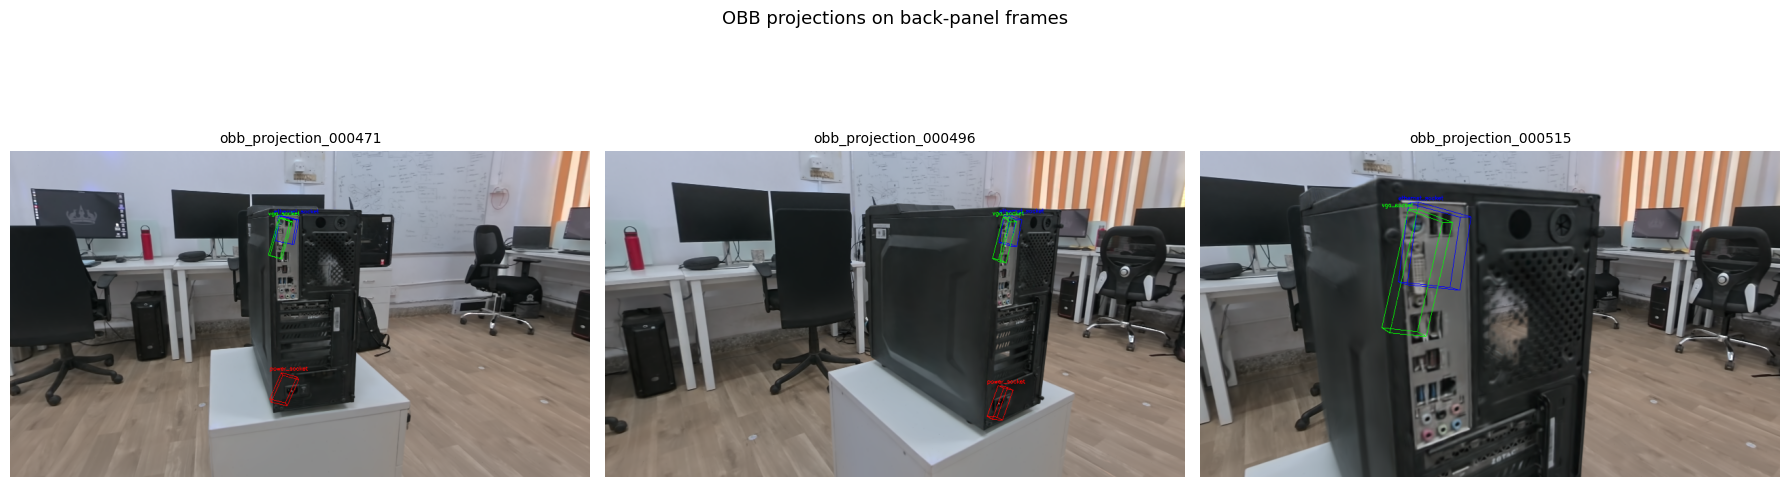


── answers.json ──
[
  {
    "entity": "power_socket",
    "obb": {
      "center": [
        0.2708955588204567,
        0.20727058934281192,
        0.5402578749033937
      ],
      "extent": [
        0.029682441599668482,
        0.018031076027311452,
        0.006
      ],
      "rotation": [
        [
          0.4142204206242773,
          0.9000349157117599,
          -0.13549388781628563
        ],
        [
          0.029719786818597417,
          0.13541137480578777,
          0.9903436241238006
        ],
        [
          0.9096912538788097,
          -0.4142474020027365,
          0.029341310804726416
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.28196334499701864,
        0.2246744750301212,
        0.849515487267156
      ],
      "extent": [
        0.022527307002642962,
        0.017686075307721913,
        0.006
      ],
      "rotation": [
        [
          0.2078100380505025,
          0.9689848272

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ── Cell 6: Show OBB projections inline + download answers.json ───────────────
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import src.config as cfg
from google.colab import files

proj_dir = Path(cfg.OUTPUT_DIR) / "detections"
proj_imgs = sorted(proj_dir.glob("obb_projection_*.png"))
if proj_imgs:
    fig, axes = plt.subplots(1, len(proj_imgs), figsize=(18, 6))
    if len(proj_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, proj_imgs):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        # Downscale for display
        h, w = img.shape[:2]
        img  = cv2.resize(img, (w//3, h//3))
        ax.imshow(img)
        ax.set_title(p.stem, fontsize=10)
        ax.axis("off")
    plt.suptitle("OBB projections on back-panel frames", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No OBB projection images found — run Cell 5 first")

# Print final answers
import json
answers_path = Path(cfg.OUTPUT_DIR) / "answers.json"
if answers_path.exists():
    print("\n── answers.json ──")
    print(json.dumps(json.loads(answers_path.read_text()), indent=2))
    print("\n📥 Downloading answers.json...")
    files.download(str(answers_path))
else:
    print("[ERROR] answers.json not found — run Cell 5 first")

In [11]:
# ── Cell 7 (Optional): Add bonus entity on exam day ──────────────────────────
# On exam day, look at the frame images and find the pixel bbox for the bonus
# entity. Add it to BONUS_ANNOTATIONS below, then run this cell.

import sys, json, numpy as np
sys.path.insert(0, "/content/project")

from src.semantic       import ENTITY_ANNOTATIONS
from src.pose_estimation import triangulate_roi_multiview, fit_obb_with_depth
from src.data_loader    import load_dataset
from src.utils          import save_answers_json
import src.config as cfg
from pathlib import Path

# ── FILL IN ON EXAM DAY ───────────────────────────────────────────────────────
BONUS_ENTITY = "usb_port"   # ← change to actual bonus entity
BONUS_ANNOTATIONS = {
    # Example — replace with actual pixel coords
    471: [1200, 500, 1320, 570],
    496: [1760, 500, 1880, 570],
}
# ─────────────────────────────────────────────────────────────────────────────

images, poses, K = load_dataset()

all_ann = {BONUS_ENTITY: BONUS_ANNOTATIONS}
pts = triangulate_roi_multiview(BONUS_ENTITY, all_ann, K, poses, 400)

if len(pts) >= 3:
    obb = fit_obb_with_depth(pts, BONUS_ENTITY, all_ann, K, poses)
    if obb:
        print(f"✅ {BONUS_ENTITY}")
        print(f"   Center: {np.round(obb['center'], 4).tolist()}")
        print(f"   Extent: {np.round(obb['extent'], 4).tolist()}")

        # Append to existing results and re-export
        answers_path = Path(cfg.OUTPUT_DIR) / "answers.json"
        existing = json.loads(answers_path.read_text()) if answers_path.exists() else []
        existing = [r for r in existing if r["entity"] != BONUS_ENTITY]
        existing.append({"entity": BONUS_ENTITY, "obb": obb})
        save_answers_json(existing, str(answers_path))

        from google.colab import files
        files.download(str(answers_path))
else:
    print("❌ Not enough 3D points — check bbox coordinates")

[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses
  usb_port: triangulated 400 3D points
✅ usb_port
   Center: [0.2968, 0.2154, 0.778]
   Extent: [0.0236, 0.013, 0.006]
  Saved answers to /content/project/output/answers.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ── Cell 8 (Optional): transforms.json for 3DGS ──────────────────────────────
import json, sys
sys.path.insert(0, "/content/project")

from src.data_loader import load_dataset
import src.config as cfg
from pathlib import Path

images, poses, K = load_dataset()
frame_ids = sorted(poses.keys())

frames_list = [
    {
        "file_path": str(Path(cfg.DATA_DIR) / f"frame_{fid:06d}.png"),
        "transform_matrix": poses[fid].tolist()
    }
    for fid in frame_ids
]

transforms = {
    "fl_x": float(K[0,0]), "fl_y": float(K[1,1]),
    "cx":   float(K[0,2]), "cy":   float(K[1,2]),
    "w": cfg.IMAGE_WIDTH,  "h": cfg.IMAGE_HEIGHT,
    "frames": frames_list,
}

out = Path(cfg.OUTPUT_DIR) / "transforms.json"
out.write_text(json.dumps(transforms, indent=2))
print(f"✅ transforms.json written ({len(frames_list)} frames)")

from google.colab import files
files.download(str(out))

# Uncomment to train 3DGS with nerfstudio (requires separate install):
# !ns-train gaussian-splatting --data /content/project/output --output-dir /content/project/output/gs --max-num-iterations 30000

[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses
✅ transforms.json written (16 frames)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>